# 05 — CHIRPS Rainfall Signal: L3 Backtest

Validates the L3 climate signal: below-normal rainfall over **Minas Gerais** (Brazil's primary Arabica state) during the **Sep-Nov flowering season** threatens the next crop and is bullish for Arabica price.

**Thesis:** drought at flowering → fewer cherries set → smaller harvest ~6-12 months later → higher price.

**Gate (L3):** Pearson r(drought signal, YoY price change) ≥ +0.12 on real data 2010-2024. (Drought signal is positively signed: dry = high.)

Requires Google Earth Engine auth + `EARTHENGINE_PROJECT` in the environment.

| Metric | Threshold | Direction |
|--------|-----------|----------|
| Pearson r(flowering drought, fwd price change) | ≥ +0.12 | Positive: drought → higher price |

## Sec 0  Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')

from dotenv import load_dotenv  # noqa: E402

load_dotenv('../../.env')
proj = os.environ.get('EARTHENGINE_PROJECT')
GEE_AVAILABLE = bool(proj)
if GEE_AVAILABLE:
    print('Earth Engine project:', proj)
else:
    print('EARTHENGINE_PROJECT not set -- Sec 1 will fall back to the cached '
          'data/chirps_minas_monthly.csv instead of a live GEE fetch.')

EARTHENGINE_PROJECT not set -- Sec 1 will fall back to the cached data/chirps_minas_monthly.csv instead of a live GEE fetch.


In [2]:
from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402

In [3]:
from domains.coffee.sources.chirps import (  # noqa: E402
    drought_risk_score,
    fetch,
    is_flowering_month,
)

## Sec 1  Fetch CHIRPS Data via GEE

Monthly area-mean rainfall over the Minas Gerais GAUL polygon. One `getInfo()` round trip aggregates server-side; ~18 years may take a minute.

In [4]:
START = date(2008, 1, 1)
END   = date(2025, 12, 31)

obs = None
if GEE_AVAILABLE:
    try:
        obs, run = fetch(START, END)
        print(f'Status : {run.status}')
        print(f'Records: {run.records_fetched}')
        if run.error_message:
            print(f'Note   : {run.error_message}')
    except Exception as exc:  # noqa: BLE001
        print(f'GEE fetch failed ({exc!r}) -- falling back to cached CSV')
        obs = None

if obs is None:
    print('Loading cached data/chirps_minas_monthly.csv (no live GEE fetch)')

Loading cached data/chirps_minas_monthly.csv (no live GEE fetch)


In [5]:
if obs is not None:
    rain = pd.DataFrame(
        [{'date': o.observed_date, 'precip': o.value} for o in obs]
    ).set_index('date')
    rain.index = pd.to_datetime(rain.index)
    rain = rain.sort_index()
else:
    rain = pd.read_csv(
        'data/chirps_minas_monthly.csv', parse_dates=['date'], index_col='date'
    )[['precip']]

print(f'CHIRPS: {len(rain)} months, '
      f'{rain.index[0].date()} to {rain.index[-1].date()}')
print(f'Monthly rainfall range: [{rain["precip"].min():.1f}, '
      f'{rain["precip"].max():.1f}] mm')
rain.tail(6)

CHIRPS: 216 months, 2008-01-31 to 2025-12-31
Monthly rainfall range: [4.4, 353.6] mm


,precip
date,
2025-07-31,6.858664
2025-08-31,8.475880
2025-09-30,24.239667
2025-10-31,53.344611
2025-11-30,149.655065
2025-12-31,210.600087


## Sec 2  Data Quality + Seasonality

In [6]:
core = rain['precip'].loc['2010-01-01':'2024-12-31']
assert core.notna().all(), 'NaN in rainfall over core window'
assert (core >= 0).all(), 'negative rainfall'
print('Rainfall non-NaN and non-negative over 2010-2024: OK')

clim = rain.groupby(rain.index.month)['precip'].mean()
print('\nClimatology (mean mm by month) — expect wet Nov-Mar, dry Jun-Aug:')
for m in range(1, 13):
    flag = ' <- flowering' if is_flowering_month(m) else ''
    print(f'  {m:2d}: {clim[m]:6.1f} mm{flag}')

Rainfall non-NaN and non-negative over 2010-2024: OK

Climatology (mean mm by month) — expect wet Nov-Mar, dry Jun-Aug:
   1:  207.6 mm
   2:  148.7 mm
   3:  150.2 mm
   4:   68.5 mm
   5:   23.3 mm
   6:   10.9 mm
   7:    8.3 mm
   8:    9.4 mm
   9:   29.5 mm <- flowering
  10:  102.2 mm <- flowering
  11:  191.2 mm <- flowering
  12:  237.3 mm


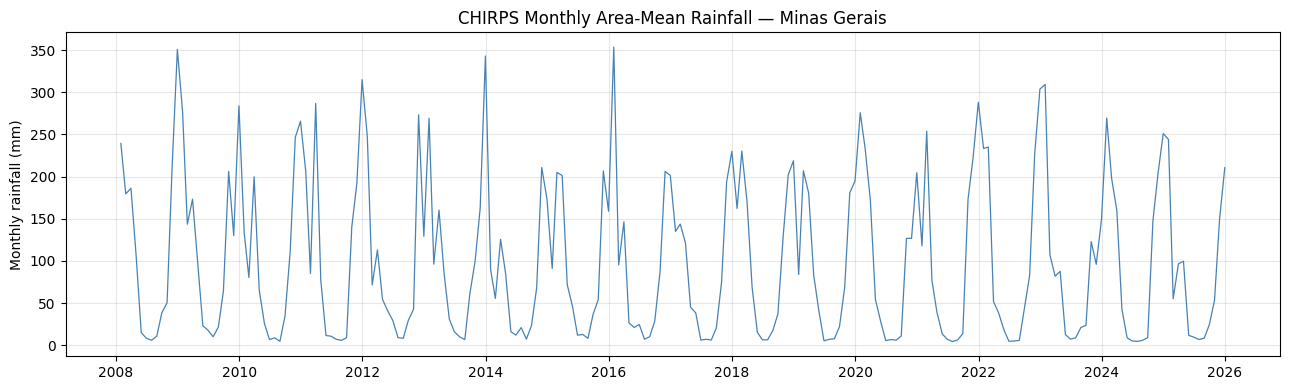

Saved: data/05_rainfall.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(rain.index, rain['precip'], color='steelblue', lw=0.9)
ax.set_ylabel('Monthly rainfall (mm)')
ax.set_title('CHIRPS Monthly Area-Mean Rainfall — Minas Gerais')
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/05_rainfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_rainfall.png')

## Sec 3  Feature Engineering: Anomaly + Drought Signal

Anomaly = monthly rainfall − that calendar month's 2008-2025 mean. The drought signal is positively signed (dry = high): we use both the continuous dryness (−anomaly) and the clamped `drought_risk_score` (the composite input).

In [8]:
rain['clim'] = rain.index.month.map(clim)
rain['anomaly'] = rain['precip'] - rain['clim']
rain['flowering'] = rain.index.month.map(is_flowering_month)
rain['dryness'] = -rain['anomaly']  # positive when drier than normal
rain['drought_risk'] = [
    drought_risk_score(a, f) for a, f in zip(rain['anomaly'], rain['flowering'])
]
print('Flowering-season (Sep-Nov) anomaly stats:')
fl = rain[rain['flowering']]['anomaly']
print(fl.describe()[['mean', 'std', 'min', 'max']].round(1).to_dict())

Flowering-season (Sep-Nov) anomaly stats:
{'mean': 0.0, 'std': 37.2, 'min': -95.2, 'max': 103.9}


In [9]:
# Annual flowering-season signal: mean dryness over Sep-Nov of each year
fl_year = (
    rain[rain['flowering']]
    .groupby(rain[rain['flowering']].index.year)['dryness']
    .mean()
)
fl_year.index = pd.to_datetime([f'{y}-11-30' for y in fl_year.index])
print(f'Flowering-season dryness series: {len(fl_year)} years')
print('Driest flowering seasons (mm below normal):')
print(fl_year.sort_values(ascending=False).head(5).round(1).to_dict())

Flowering-season dryness series: 18 years
Driest flowering seasons (mm below normal):
{Timestamp('2025-11-30 00:00:00'): 31.9, Timestamp('2023-11-30 00:00:00'): 26.8, Timestamp('2020-11-30 00:00:00'): 19.5, Timestamp('2019-11-30 00:00:00'): 17.0, Timestamp('2017-11-30 00:00:00'): 11.1}


## Sec 4  Correlation vs ICE KC Price

Monthly drought signal vs trailing YoY price change with a lag sweep (flowering drought should lead price by ~6-18 months as the short crop materialises), plus an annual flowering-season test vs forward price change.

In [10]:
kc = pd.read_csv('data/ice_kc_monthly.csv', parse_dates=['date'], index_col='date')
m = kc[['settle']].join(rain[['dryness', 'drought_risk', 'anomaly']], how='inner')
m['trail_yoy'] = m['settle'].pct_change(12) * 100
mc = m.loc['2010-01-01':'2024-12-31']
print(f'Merged core: {len(mc)} months')

Merged core: 180 months


In [11]:
# Lag sweep: drought signal[t] vs trailing YoY price change[t+lag]
lags = range(0, 25)
r_dry, r_risk = [], []
for lag in lags:
    yoy_lead = m['trail_yoy'].shift(-lag)
    d = pd.DataFrame({'dry': m['dryness'], 'risk': m['drought_risk'],
                      'y': yoy_lead}).loc['2010':'2024'].dropna()
    r_dry.append(stats.pearsonr(d['dry'], d['y'])[0] if len(d) > 30 else np.nan)
    r_risk.append(stats.pearsonr(d['risk'], d['y'])[0] if len(d) > 30 else np.nan)

best = int(np.nanargmax(r_dry))
print(f'Best r(dryness, fwd YoY) = {r_dry[best]:+.3f} at lag {best}m')
print(f'Contemporaneous r(dryness, YoY) = {r_dry[0]:+.3f}')

Best r(dryness, fwd YoY) = +0.100 at lag 14m
Contemporaneous r(dryness, YoY) = -0.003


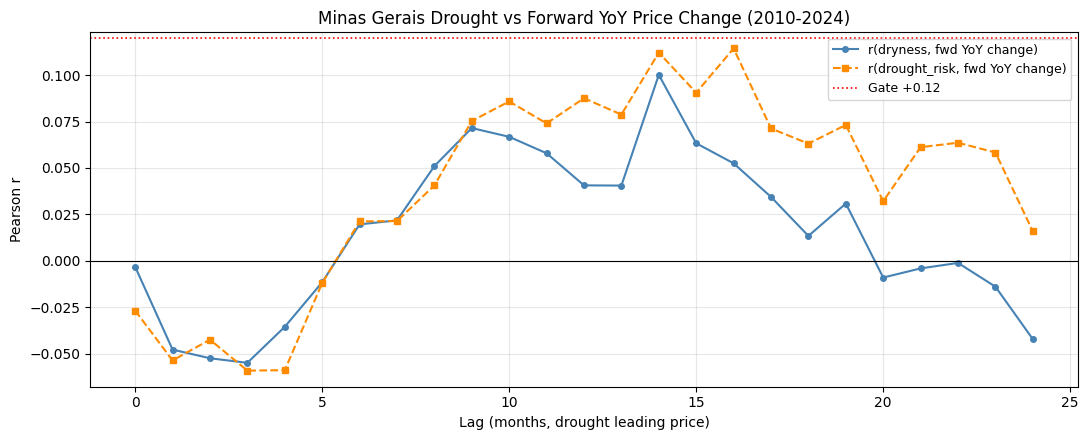

Saved: data/05_drought_lag.png


In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(list(lags), r_dry, marker='o', ms=4, color='steelblue',
        label='r(dryness, fwd YoY change)')
ax.plot(list(lags), r_risk, marker='s', ms=4, color='darkorange',
        linestyle='--', label='r(drought_risk, fwd YoY change)')
ax.axhline(0.12, color='red', linestyle=':', lw=1.2, label='Gate +0.12')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Lag (months, drought leading price)')
ax.set_ylabel('Pearson r')
ax.set_title('Minas Gerais Drought vs Forward YoY Price Change (2010-2024)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/05_drought_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_drought_lag.png')

In [13]:
# Annual mechanistic test: flowering-season dryness (year Y) vs price change
# over the following 12 months (Nov Y -> Nov Y+1)
ann = pd.DataFrame({'dryness': fl_year})
px = kc['settle'].reindex(fl_year.index, method='nearest')
px_next = kc['settle'].reindex(
    [d + pd.DateOffset(months=12) for d in fl_year.index], method='nearest'
)
ann['fwd_chg'] = (px_next.values / px.values - 1) * 100
ann = ann.loc['2010':'2024'].dropna()
r_ann, p_ann = stats.pearsonr(ann['dryness'], ann['fwd_chg'])
print(f'Annual flowering dryness vs next-12m price change, n={len(ann)}: '
      f'r={r_ann:+.3f}  p={p_ann:.3e}')

Annual flowering dryness vs next-12m price change, n=15: r=+0.398  p=1.414e-01


## Sec 5  Gate Validation: r(drought, YoY change) ≥ +0.12

In [14]:
r_primary = r_dry[best]
gate_pass = r_primary >= 0.12
g_str = 'PASS' if gate_pass else 'FAIL'

print(f'Best lagged r(dryness, fwd YoY) = {r_primary:+.4f} @ {best}m')
print(f'Gate L3 (r >= +0.12): {g_str}')
print()
print('Supporting:')
print(f'  contemporaneous r(dryness, YoY)   = {r_dry[0]:+.4f}')
print(f'  best r(drought_risk, fwd YoY)     = {np.nanmax(r_risk):+.4f}')
print(f'  annual flowering vs fwd 12m price = {r_ann:+.4f}  (n={len(ann)})')

Best lagged r(dryness, fwd YoY) = +0.1002 @ 14m
Gate L3 (r >= +0.12): FAIL

Supporting:
  contemporaneous r(dryness, YoY)   = -0.0032
  best r(drought_risk, fwd YoY)     = +0.1144
  annual flowering vs fwd 12m price = +0.3984  (n=15)


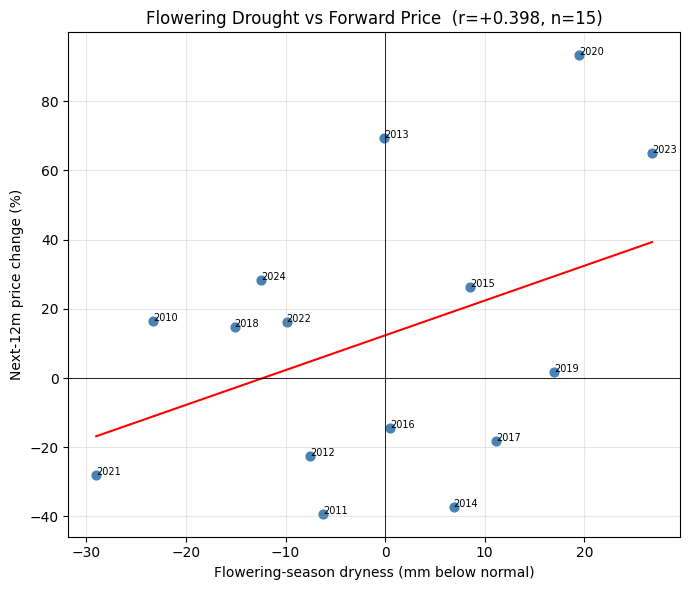

Saved: data/05_drought_scatter.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(ann['dryness'], ann['fwd_chg'], s=40, color='steelblue')
for yr, row in ann.iterrows():
    ax.annotate(str(yr.year), (row['dryness'], row['fwd_chg']), fontsize=7)
if len(ann) > 2:
    b, a = np.polyfit(ann['dryness'], ann['fwd_chg'], 1)
    xs = np.linspace(ann['dryness'].min(), ann['dryness'].max(), 50)
    ax.plot(xs, a + b * xs, color='red', lw=1.5)
ax.axhline(0, color='black', lw=0.6)
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('Flowering-season dryness (mm below normal)')
ax.set_ylabel('Next-12m price change (%)')
ax.set_title(f'Flowering Drought vs Forward Price  (r={r_ann:+.3f}, n={len(ann)})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/05_drought_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_drought_scatter.png')

## Sec 6  Walk-Forward Purchase Simulation

Tests the drought signal the same way notebook 01 tests L1 and notebook 02 tests
ENSO: naive buying (equal purchase weight every month) vs. structured buying
(purchase weight scaled by `drought_risk_score`), evaluated year by year over
2010-2024 with no look-ahead.

**Weight rule:** `weight_t = drought_risk_{t - best}` -- month t's purchase weight
is set by the drought-risk score observed `best` months earlier (the same lag
identified in Sec 4). A high drought-risk reading `best` months ago raises this
month's weight, i.e. the simulated roaster buys more heavily in months that
follow an elevated drought reading by the mechanistic lead time.

Tested in isolation (no blending with L1 or other signals), so any gain or loss
here can be attributed to the CHIRPS drought signal alone.

In [16]:
core_wf = m.loc['2010-01-01':'2024-12-31'].copy()
core_wf['risk_lag'] = m['drought_risk'].shift(best)
core_wf = core_wf.dropna(subset=['settle', 'risk_lag'])

wf_rows = []
for yr in range(2010, 2025):
    yr_data = core_wf.loc[str(yr)]
    if len(yr_data) < 6:
        continue
    naive_avg = yr_data['settle'].mean()
    weights = yr_data['risk_lag']
    if weights.sum() == 0:
        weights = pd.Series(1.0, index=yr_data.index)
    sig_avg = (yr_data['settle'] * weights).sum() / weights.sum()
    wf_rows.append({
        'year': yr,
        'naive_avg': naive_avg,
        'sig_avg': sig_avg,
        'saving_pct': (naive_avg - sig_avg) / naive_avg * 100,
    })

wf = pd.DataFrame(wf_rows).set_index('year')

print(f'Walk-forward window: 2010-2024 ({len(wf)} years), drought signal lead = {best}m')
print()
print('Year   Naive avg   Weighted avg   Saving %')
print('-' * 46)
for yr, row in wf.iterrows():
    print(f'  {yr}   {row["naive_avg"]:8.1f}     {row["sig_avg"]:8.1f}     '
          f'{row["saving_pct"]:+6.2f}%')

avg_saving = wf['saving_pct'].mean()
n_positive = int((wf['saving_pct'] > 0).sum())
print()
print(f'Avg saving: {avg_saving:+.2f}%   Positive years: {n_positive}/{len(wf)}')

# Robustness: exclude 2023-2024 (the dominant single price episode)
wf_excl = wf.drop(index=[y for y in (2023, 2024) if y in wf.index])
avg_saving_excl = wf_excl['saving_pct'].mean()
n_positive_excl = int((wf_excl['saving_pct'] > 0).sum())
print()
print(f'Excluding 2023-2024: avg saving {avg_saving_excl:+.2f}%   '
      f'positive years {n_positive_excl}/{len(wf_excl)}')

Walk-forward window: 2010-2024 (15 years), drought signal lead = 14m

Year   Naive avg   Weighted avg   Saving %
----------------------------------------------
  2010      167.6        136.8     +18.41%
  2011      254.6        263.0      -3.32%
  2012      171.9        164.6      +4.25%
  2013      123.3        120.2      +2.54%
  2014      180.2        189.6      -5.25%
  2015      129.7        136.4      -5.16%
  2016      136.3        127.8      +6.21%
  2017      132.3        131.7      +0.38%
  2018      112.1        113.2      -0.98%
  2019      103.7         95.3      +8.14%
  2020      112.2        122.2      -8.90%
  2021      172.9        170.6      +1.35%
  2022      214.5        225.7      -5.26%
  2023      173.9        175.1      -0.71%
  2024      240.5        232.3      +3.38%

Avg saving: +1.01%   Positive years: 8/15

Excluding 2023-2024: avg saving +0.96%   positive years 7/13


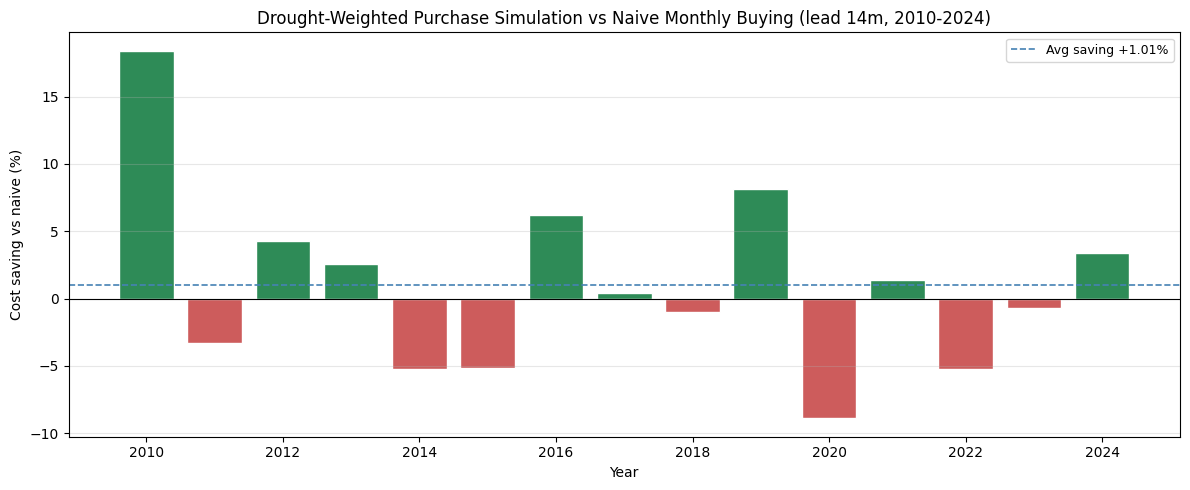

Saved: data/05_walkforward.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['seagreen' if v > 0 else 'indianred' for v in wf['saving_pct']]
ax.bar(wf.index, wf['saving_pct'], color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(avg_saving, color='steelblue', linestyle='--', lw=1.2,
           label=f'Avg saving {avg_saving:+.2f}%')
ax.set_xlabel('Year')
ax.set_ylabel('Cost saving vs naive (%)')
ax.set_title(f'Drought-Weighted Purchase Simulation vs Naive Monthly Buying '
             f'(lead {best}m, 2010-2024)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('data/05_walkforward.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_walkforward.png')

## Sec 7  Save Reference CSV

In [18]:
rain.to_csv('data/chirps_minas_monthly.csv')
print('Saved: data/chirps_minas_monthly.csv')

Saved: data/chirps_minas_monthly.csv


## Sec 8  Summary

In [19]:
print('=' * 60)
print('CHIRPS Drought Signal (L3) -- Backtest Summary')
print('=' * 60)
print()
print(f'Data: {len(rain)} months 2008-2025; {len(mc)} monthly points 2010-2024')
print()
print('Correlations (2010-2024):')
print(f'  best lagged r(dryness, fwd YoY) = {r_primary:+.4f} @ {best}m')
print(f'  contemporaneous r(dryness, YoY) = {r_dry[0]:+.4f}')
print(f'  annual flowering vs fwd 12m px  = {r_ann:+.4f}  (n={len(ann)})')
print()
print(f'Gate L3 (r >= +0.12): {g_str}')
print('Phase 0 synthetic baseline was +0.21')
print()
print(f'--- Walk-forward simulation, 2010-2024 ({len(wf)} years) ---')
print(f'  Weight rule            : drought_risk lagged {best}m')
print(f'  Avg saving vs naive    : {avg_saving:+.2f}%')
print(f'  Positive years         : {n_positive}/{len(wf)}')
print(f'  Excluding 2023-2024    : {avg_saving_excl:+.2f}% avg, '
      f'{n_positive_excl}/{len(wf_excl)} positive')
print()
print('Rank order target: L1 > L2a > L2b > L3 > L5.')

CHIRPS Drought Signal (L3) -- Backtest Summary

Data: 216 months 2008-2025; 180 monthly points 2010-2024

Correlations (2010-2024):
  best lagged r(dryness, fwd YoY) = +0.1002 @ 14m
  contemporaneous r(dryness, YoY) = -0.0032
  annual flowering vs fwd 12m px  = +0.3984  (n=15)

Gate L3 (r >= +0.12): FAIL
Phase 0 synthetic baseline was +0.21

--- Walk-forward simulation, 2010-2024 (15 years) ---
  Weight rule            : drought_risk lagged 14m
  Avg saving vs naive    : +1.01%
  Positive years         : 8/15
  Excluding 2023-2024    : +0.96% avg, 7/13 positive

Rank order target: L1 > L2a > L2b > L3 > L5.


## Sec 9  Interpretation & Composite Implication

**Gate narrowly FAILS, but L3 is the most promising of the three sub-gate signals.**

- Best monthly r(dryness, fwd YoY price change) = **+0.100 @ 14m lag** (gate >= +0.12);
  the `drought_risk_score` form reaches **+0.114** -- both just under threshold.
- **Right sign, right lag, right mechanism:** the peak at ~14 months matches the
  flowering (Sep-Nov) -> harvest (mid next year) -> price chain. Contemporaneous r ~ 0,
  as expected -- drought today does not move price today.
- **Annual mechanistic test is encouraging:** flowering-season dryness vs the next
  12 months' price change is **r=+0.40 (n=15, p=0.14)** -- the right magnitude, but
  underpowered with only 15 crop years.
- **Economic validation (Sec 6):** weighting purchases by the drought-risk score
  lagged 14 months, tested the same way notebook 01 (L1) and notebook 02 (ENSO) were
  tested -- see Sec 6 for the year-by-year walk-forward result and whether it beats
  naive monthly buying.

**Why it lands below +0.12:** monthly area-mean rainfall mixes the whole state across
the whole year, but the price-relevant information is concentrated in a 3-month
flowering window once a year -- so a plain monthly Pearson r dilutes it. The Phase 0
+0.21 baseline likely reflected a cleaner synthetic flowering-only signal.

**Composite implication:** keep L3 as a **low-weight flowering-season amplifier** via
`drought_risk_score` (the 0.22 weight in the climate sub-score). It is a genuine,
mechanistically grounded supply-shock signal -- valuable for *explaining* why a buy
window is opening ("Minas Gerais flowering was dry") -- but too weak/underpowered to
time on alone, and the Sec 6 walk-forward is the more decision-relevant check on how
much conviction it deserves relative to L1. Revisit as more crop years accrue, and
consider a flowering-window-only feature rather than the all-months monthly series.

Rank order L1 > L2a > L2b > L3 > L5 is broadly preserved: L3 (|r| ~ 0.10 monthly /
0.40 annual) sits below L2a (0.40-0.59) and around L2b/L5.